# Project Delay Random Forest Models from Top Correlates

This notebook uses the corrected all-customer project delay correlates dataset and builds random-forest models from a reduced feature set:

- Top 20 positive Spearman-correlated candidate fields with `PERCENTDELAYED`.
- Top 20 negative Spearman-correlated candidate fields with `PERCENTDELAYED`.

Two modeling tasks are run:

- Continuous regression target: `PERCENTDELAYED`.
- Binary classification target: `PERCENTDELAYED > 0`, meaning actual duration exceeded planned duration.

Two feature scenarios are compared:

- **All top-correlate fields**: includes everything selected by correlation, even if it is retrospective or payment-history dependent.
- **Usable-only fields**: removes fields that are unlikely to be available before payment history begins; the notebook documents the viability of each field.

The split is deterministic by `CustomerName + ProjectName` hash for reproducibility.

In [1]:
import csv, math, hashlib, os, re
from pathlib import Path
from collections import Counter
import numpy as np
from IPython.display import display, HTML, SVG

try:
    import sklearn
    from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import (
        mean_absolute_error, mean_squared_error, r2_score,
        accuracy_score, balanced_accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, confusion_matrix
    )
except Exception as e:
    raise RuntimeError('scikit-learn is required for this notebook. Install scikit-learn and rerun.') from e

DATA_FILE = Path('custpaydetails_project_delay_correlates_allcustomers_hardcoded_keywords_2026-06-08-1224.csv')
CORR_FILE = Path('project_delay_correlation_analysis_allcustomers_percentdelayed_candidate_correlations.csv')
OUT_PREFIX = 'project_delay_random_forest_top_correlates'
RANDOM_STATE = 20260608

In [2]:
def esc(x):
    return str(x).replace('&','&amp;').replace('<','&lt;').replace('>','&gt;').replace('"','&quot;')

def fmt(x, d=4):
    if x is None: return ''
    try:
        xf=float(x)
    except Exception:
        return esc(x)
    if not math.isfinite(xf): return ''
    if abs(xf)>=1000: return f'{xf:,.2f}'
    if abs(xf)>=10: return f'{xf:,.2f}'
    return f'{xf:,.{d}f}'

def table(rows, cols=None, title=None, max_rows=30):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    parts=[]
    if title: parts.append('<h3>'+esc(title)+'</h3>')
    parts.append('<div style="overflow-x:auto"><table style="border-collapse:collapse;font-size:12px">')
    parts.append('<tr>' + ''.join('<th style="border-bottom:1px solid #999;padding:4px 7px;text-align:left;white-space:nowrap">'+esc(c)+'</th>' for c in cols) + '</tr>')
    for r in rows[:max_rows]:
        parts.append('<tr>')
        for c in cols:
            v=r.get(c,'')
            align='right' if isinstance(v,(int,float,np.integer,np.floating)) else 'left'
            parts.append('<td style="border-bottom:1px solid #ddd;padding:3px 7px;text-align:'+align+';white-space:nowrap">'+fmt(v)+'</td>')
        parts.append('</tr>')
    parts.append('</table></div>')
    if len(rows)>max_rows:
        parts.append('<p style="font-size:12px;color:#555">Showing '+format(max_rows, ',')+' of '+format(len(rows), ',')+' rows.</p>')
    return HTML('\\n'.join(parts))

def write_csv(path, rows, cols=None):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    with open(path,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for r in rows:
            w.writerow({c:r.get(c,'') for c in cols})

def to_float(v):
    s=str(v).strip() if v is not None else ''
    if not s or s.upper() in {'NULL','NAN','NONE'}: return np.nan
    try: return float(s.replace(',',''))
    except Exception: return np.nan

def stable_test_split(customer, project, test_pct=20):
    key=(str(customer)+'|'+str(project)).encode('utf-8')
    return int(hashlib.sha256(key).hexdigest()[:12], 16) % 100 < test_pct

def metric_bar(rows, value_col, label_col='scenario', title='', width=760, height=260, color='#3f6f9f'):
    rows=list(rows)
    vals=[float(r[value_col]) for r in rows if r.get(value_col) not in ['',None] and math.isfinite(float(r[value_col]))]
    if not vals: return SVG('<svg/>')
    maxv=max(max(vals), 1e-9)
    ml, mr, mt, mb = 230, 30, 34, 28
    w, h = width-ml-mr, height-mt-mb
    rh = h / max(len(rows),1)
    parts=[]
    for i,r in enumerate(rows):
        v=float(r[value_col])
        y=mt+i*rh+rh*0.18
        bw=(v/maxv)*w
        parts.append('<text x="'+str(ml-8)+'" y="'+format(y+rh*0.58,'.1f')+'" text-anchor="end" font-size="11">'+esc(r[label_col])+'</text>')
        parts.append('<rect x="'+str(ml)+'" y="'+format(y,'.1f')+'" width="'+format(bw,'.1f')+'" height="'+format(rh*0.68,'.1f')+'" fill="'+color+'" opacity="0.85"/>')
        parts.append('<text x="'+format(ml+bw+5,'.1f')+'" y="'+format(y+rh*0.58,'.1f')+'" font-size="11">'+fmt(v,3)+'</text>')
    body=''.join(parts)
    return SVG('<svg width="'+str(width)+'" height="'+str(height)+'" xmlns="http://www.w3.org/2000/svg"><style>text{font-family:Arial,sans-serif}</style><text x="'+str(ml)+'" y="22" font-size="15" font-weight="600">'+esc(title)+'</text>'+body+'</svg>')

## Load Data and Select Features

The selected feature set comes from the prior correlation notebook output, not from re-running correlation selection inside this notebook. This keeps the modeling notebook aligned with the previous exploratory result.

In [3]:
with open(DATA_FILE, newline='', encoding='utf-8-sig') as f:
    reader=csv.DictReader(f)
    rows=list(reader)
    data_cols=reader.fieldnames

with open(CORR_FILE, newline='', encoding='utf-8') as f:
    corr_rows=list(csv.DictReader(f))

pos = [r for r in corr_rows if float(r['spearman_r']) > 0]
pos = sorted(pos, key=lambda r: -float(r['spearman_r']))[:20]
neg = [r for r in corr_rows if float(r['spearman_r']) < 0]
neg = sorted(neg, key=lambda r: float(r['spearman_r']))[:20]
selected = []
seen=set()
for r in pos + neg:
    if r['feature'] not in seen:
        selected.append(r)
        seen.add(r['feature'])
features = [r['feature'] for r in selected]

raw = {c:[row.get(c,'') for row in rows] for c in data_cols}
num = {c:np.array([to_float(v) for v in raw[c]], dtype=float) for c in data_cols if c not in {'CUSTOMERNAME','PROJECTNAME'}}
for c in data_cols:
    if '_KW_' in c and c in num:
        num[c] = np.where(np.isfinite(num[c]), num[c], 0.0)

split_test = np.array([stable_test_split(r.get('CUSTOMERNAME'), r.get('PROJECTNAME')) for r in rows], dtype=bool)
split_train = ~split_test
y = num['PERCENTDELAYED']
y_binary = (y > 0).astype(int)

overview = [
    {'metric':'project rows', 'value':len(rows)},
    {'metric':'columns', 'value':len(data_cols)},
    {'metric':'selected top positive features', 'value':len(pos)},
    {'metric':'selected top negative features', 'value':len(neg)},
    {'metric':'unique selected features', 'value':len(features)},
    {'metric':'train rows', 'value':int(split_train.sum())},
    {'metric':'test rows', 'value':int(split_test.sum())},
    {'metric':'train delayed share', 'value':float(y_binary[split_train].mean())},
    {'metric':'test delayed share', 'value':float(y_binary[split_test].mean())},
]
display(table(overview, ['metric','value'], 'Dataset and split overview'))
display(table([{'rank':i+1,'direction':'positive','feature':r['feature'],'spearman_r':float(r['spearman_r']),'class':r['class']} for i,r in enumerate(pos)] + [{'rank':i+1,'direction':'negative','feature':r['feature'],'spearman_r':float(r['spearman_r']),'class':r['class']} for i,r in enumerate(neg)], ['direction','rank','feature','spearman_r','class'], 'Selected top-correlation features', max_rows=45))

metric,value
project rows,"3,331.00"
columns,394.00
selected top positive features,20.00
selected top negative features,20.00
unique selected features,40.00
train rows,"2,683.00"
test rows,648.00
train delayed share,0.5449
test delayed share,0.5370


direction,rank,feature,spearman_r,class
positive,1.0000,PAYDATESPERPLANNEDMONTH,0.8543,numeric predictor
positive,2.0000,DOLLARSPERPLANNEDDAY,0.7953,numeric predictor
positive,3.0000,DOLLARSPERPLANNEDMONTH,0.7953,numeric predictor
positive,4.0000,AVGUNITPRICE,0.7510,numeric predictor
positive,5.0000,CI_KW_MOBILIZATION,0.7473,keyword: CI.DESCRIPTION
positive,6.0000,ITEMENDSPREADDAYS,0.7465,numeric predictor
positive,7.0000,MAXUNITPRICE,0.7423,numeric predictor
positive,8.0000,STDDEVUNITPRICE,0.7406,numeric predictor
positive,9.0000,MINCONTRACTBURN,0.7306,numeric predictor
positive,10.00,AVGCONTRACTBURN,0.7273,numeric predictor


## Field Viability Assessment

This table classifies whether each selected field is usable in a real forward-looking environment. The key distinction is whether the field can be known at project setup/contract setup, or whether it requires observing completed payment history.

In [4]:
def viability(feature):
    f=feature.upper()
    if f.startswith('CI_KW_'):
        return ('potentially usable after contract item setup', 'Derived from contract item descriptions; usable only if item text is available before prediction time.')
    if f.startswith('PM_KW_'):
        return ('likely usable at project setup', 'Derived from project description text, usually available early.')
    if f.startswith('CM_KW_'):
        return ('likely usable at contract setup', 'Derived from contract name/description, usually available before payment history.')
    if f in {'PLANNEDDURATIONDAYS'}:
        return ('likely usable at project setup', 'Derived from planned start/end dates.')
    if 'DESCRIPTIONTOKENCOUNT' in f or 'TEXTTOKENCOUNT' in f:
        return ('likely usable from setup text', 'Text-length/count feature from project/contract descriptions.')
    if 'UNITPRICE' in f or 'CONTRACTQUANTITY' in f or 'CONTRACTITEMPLANNEDVALUE' in f or 'MISSINGORZEROPLANNEDVALUE' in f:
        return ('potentially usable after contract item setup', 'Depends on item-level estimate/contract setup quality; not available before item schedule is defined.')
    payment_terms = ['PAYDATE','PAYDATES','PAYMENT','POSTING','BURN','DOLLARSPERPLANNED','CONTRACTBURN','ITEMBURN','ITEMENDSPREAD','ITEMSTARTSPREAD','TOTALBURN','ZEROTOTALBURN']
    if any(t in f for t in payment_terms):
        return ('not usable before payment history', 'Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.')
    return ('needs business review', 'Availability depends on when this field is populated in the operational workflow.')

viability_rows=[]
for r in selected:
    status, note = viability(r['feature'])
    viability_rows.append({'feature':r['feature'], 'direction':'positive' if float(r['spearman_r'])>0 else 'negative', 'spearman_r':float(r['spearman_r']), 'class':r['class'], 'viability':status, 'comment':note})
usable_features = [r['feature'] for r in viability_rows if not r['viability'].startswith('not usable')]
unusable_features = [r['feature'] for r in viability_rows if r['viability'].startswith('not usable')]
write_csv(f'{OUT_PREFIX}_field_viability.csv', viability_rows)
display(table(viability_rows, ['feature','direction','spearman_r','class','viability','comment'], 'Field viability notes', max_rows=45))
display(table([{'metric':'features in all-top scenario','value':len(features)}, {'metric':'features removed as not usable before payment history','value':len(unusable_features)}, {'metric':'features retained in usable-only scenario','value':len(usable_features)}], ['metric','value'], 'Feature scenario sizes'))

feature,direction,spearman_r,class,viability,comment
PAYDATESPERPLANNEDMONTH,positive,0.8543,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
DOLLARSPERPLANNEDDAY,positive,0.7953,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
DOLLARSPERPLANNEDMONTH,positive,0.7953,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
AVGUNITPRICE,positive,0.7510,numeric predictor,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
CI_KW_MOBILIZATION,positive,0.7473,keyword: CI.DESCRIPTION,potentially usable after contract item setup,Derived from contract item descriptions; usable only if item text is available before prediction time.
ITEMENDSPREADDAYS,positive,0.7465,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
MAXUNITPRICE,positive,0.7423,numeric predictor,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVUNITPRICE,positive,0.7406,numeric predictor,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
MINCONTRACTBURN,positive,0.7306,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
AVGCONTRACTBURN,positive,0.7273,numeric predictor,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.


metric,value
features in all-top scenario,40.00
features removed as not usable before payment history,17.00
features retained in usable-only scenario,23.00


## Model Training Function

Both regression and classification use random forests with median imputation. Trees do not require scaling. The split is deterministic by hash and is not reshuffled inside the notebook.

In [5]:
def make_X(feature_list):
    return np.column_stack([num[f] for f in feature_list]).astype(float)

def baseline_regression(y_train, y_test):
    pred=np.full_like(y_test, np.nanmedian(y_train), dtype=float)
    return {
        'mae':float(mean_absolute_error(y_test, pred)),
        'rmse':float(math.sqrt(mean_squared_error(y_test, pred))),
        'r2':float(r2_score(y_test, pred)),
        'bias':float(np.mean(pred-y_test)),
    }

def baseline_classification(y_train, y_test):
    majority=int(np.round(np.mean(y_train)) >= 1)
    pred=np.full_like(y_test, majority, dtype=int)
    return {
        'accuracy':float(accuracy_score(y_test, pred)),
        'balanced_accuracy':float(balanced_accuracy_score(y_test, pred)),
        'precision':float(precision_score(y_test, pred, zero_division=0)),
        'recall':float(recall_score(y_test, pred, zero_division=0)),
        'f1':float(f1_score(y_test, pred, zero_division=0)),
        'roc_auc':np.nan,
    }

def run_models(name, feature_list):
    X=make_X(feature_list)
    mask=np.isfinite(y) & np.isfinite(y_binary)
    train=split_train & mask
    test=split_test & mask
    Xtr, Xte = X[train], X[test]
    ytr, yte = y[train], y[test]
    ybtr, ybte = y_binary[train], y_binary[test]
    reg = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=400, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    clf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1))
    ])
    reg.fit(Xtr, ytr)
    clf.fit(Xtr, ybtr)
    pred_reg=reg.predict(Xte)
    pred_cls=clf.predict(Xte)
    pred_prob=clf.predict_proba(Xte)[:,1]
    reg_metrics={
        'scenario':name, 'task':'regression', 'features':len(feature_list), 'train_rows':int(train.sum()), 'test_rows':int(test.sum()),
        'mae':float(mean_absolute_error(yte, pred_reg)),
        'rmse':float(math.sqrt(mean_squared_error(yte, pred_reg))),
        'r2':float(r2_score(yte, pred_reg)),
        'bias_pred_minus_actual':float(np.mean(pred_reg-yte)),
        'baseline_mae':baseline_regression(ytr,yte)['mae'],
        'baseline_rmse':baseline_regression(ytr,yte)['rmse'],
        'baseline_r2':baseline_regression(ytr,yte)['r2'],
    }
    cls_metrics={
        'scenario':name, 'task':'classification', 'features':len(feature_list), 'train_rows':int(train.sum()), 'test_rows':int(test.sum()),
        'accuracy':float(accuracy_score(ybte, pred_cls)),
        'balanced_accuracy':float(balanced_accuracy_score(ybte, pred_cls)),
        'precision':float(precision_score(ybte, pred_cls, zero_division=0)),
        'recall':float(recall_score(ybte, pred_cls, zero_division=0)),
        'f1':float(f1_score(ybte, pred_cls, zero_division=0)),
        'roc_auc':float(roc_auc_score(ybte, pred_prob)) if len(np.unique(ybte))>1 else np.nan,
        'baseline_accuracy':baseline_classification(ybtr,ybte)['accuracy'],
        'baseline_balanced_accuracy':baseline_classification(ybtr,ybte)['balanced_accuracy'],
    }
    reg_imp=reg.named_steps['model'].feature_importances_
    clf_imp=clf.named_steps['model'].feature_importances_
    importances=[]
    for f,ri,ci in zip(feature_list, reg_imp, clf_imp):
        status,note=viability(f)
        importances.append({'scenario':name,'feature':f,'regression_importance':float(ri),'classification_importance':float(ci),'viability':status,'comment':note})
    pred_rows=[]
    for idx, pr, pc, pp in zip(np.where(test)[0], pred_reg, pred_cls, pred_prob):
        pred_rows.append({'scenario':name,'CUSTOMERNAME':raw['CUSTOMERNAME'][idx],'PROJECTNAME':raw['PROJECTNAME'][idx],'actual_percent_delayed':float(y[idx]),'predicted_percent_delayed':float(pr),'actual_delayed':int(y_binary[idx]),'predicted_delayed':int(pc),'predicted_delay_probability':float(pp)})
    return reg_metrics, cls_metrics, importances, pred_rows

## Train Models

The first scenario intentionally includes retrospective fields. The second scenario removes features classified as not usable before payment history, which is closer to a real forward-looking deployment setting.

scenario,features,train_rows,test_rows,mae,rmse,r2,bias_pred_minus_actual,baseline_mae,baseline_rmse,baseline_r2
all_top_20_pos_20_neg,40.00,"2,683.00",648.00,29.39,106.84,0.8310,4.2306,164.62,269.33,-0.0737
usable_only_removed_payment_history_fields,23.00,"2,683.00",648.00,98.50,190.09,0.4652,4.3554,164.62,269.33,-0.0737


scenario,features,train_rows,test_rows,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,baseline_accuracy,baseline_balanced_accuracy
all_top_20_pos_20_neg,40.00,"2,683.00",648.00,0.9444,0.9437,0.9432,0.9540,0.9486,0.9905,0.5370,0.5000
usable_only_removed_payment_history_fields,23.00,"2,683.00",648.00,0.9136,0.9124,0.9124,0.9282,0.9202,0.9698,0.5370,0.5000


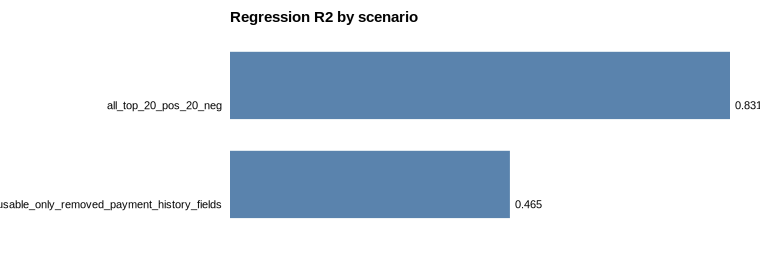

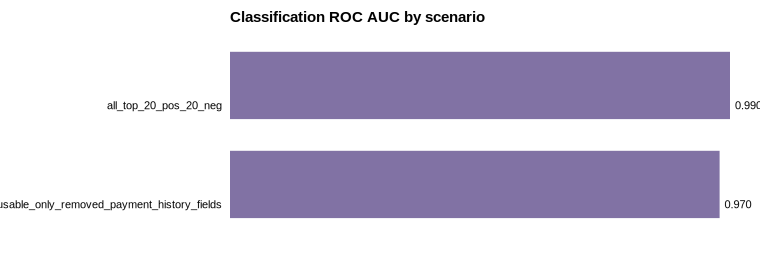

In [6]:
scenarios = [
    ('all_top_20_pos_20_neg', features),
    ('usable_only_removed_payment_history_fields', usable_features),
]
reg_metrics=[]; cls_metrics=[]; all_importances=[]; all_predictions=[]
for name, feats in scenarios:
    rm, cm, imps, preds = run_models(name, feats)
    reg_metrics.append(rm); cls_metrics.append(cm); all_importances.extend(imps); all_predictions.extend(preds)

write_csv(f'{OUT_PREFIX}_regression_metrics.csv', reg_metrics)
write_csv(f'{OUT_PREFIX}_classification_metrics.csv', cls_metrics)
write_csv(f'{OUT_PREFIX}_feature_importances.csv', all_importances)
write_csv(f'{OUT_PREFIX}_test_predictions.csv', all_predictions)

display(table(reg_metrics, ['scenario','features','train_rows','test_rows','mae','rmse','r2','bias_pred_minus_actual','baseline_mae','baseline_rmse','baseline_r2'], 'Regression performance on held-out hash test set'))
display(table(cls_metrics, ['scenario','features','train_rows','test_rows','accuracy','balanced_accuracy','precision','recall','f1','roc_auc','baseline_accuracy','baseline_balanced_accuracy'], 'Binary delayed/not-delayed classification performance on held-out hash test set'))
display(metric_bar(reg_metrics, 'r2', title='Regression R2 by scenario'))
display(metric_bar(cls_metrics, 'roc_auc', title='Classification ROC AUC by scenario', color='#6b5b95'))

## Graphical Model Performance Diagnostics

This section visualizes the held-out test predictions for both random-forest scenarios.

For the binary delayed/not-delayed model, the ROC curves show what happens as the decision threshold is swept across predicted probabilities. The area under each ROC curve is the AUC reported in the metrics table.

For the continuous `PERCENTDELAYED` model, the parity and residual plots show whether predictions are calibrated across the observed delay range or whether performance is concentrated in the middle of the distribution.

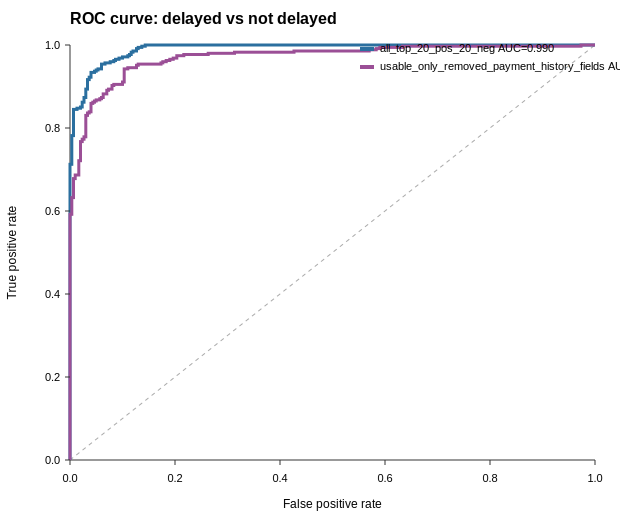

scenario,roc_auc,average_precision,test_rows,positive_rate
all_top_20_pos_20_neg,0.9905,0.9918,648.00,0.5370
usable_only_removed_payment_history_fields,0.9698,0.9769,648.00,0.5370


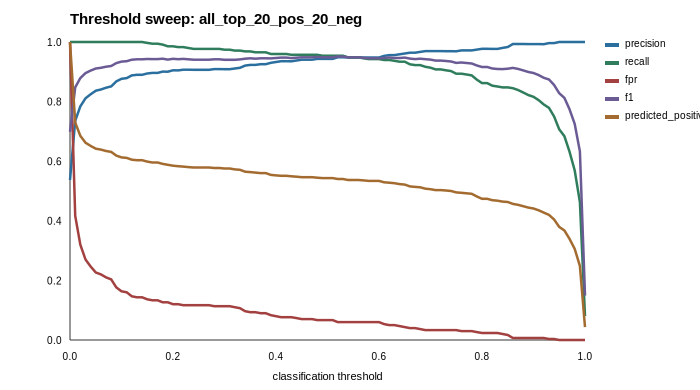

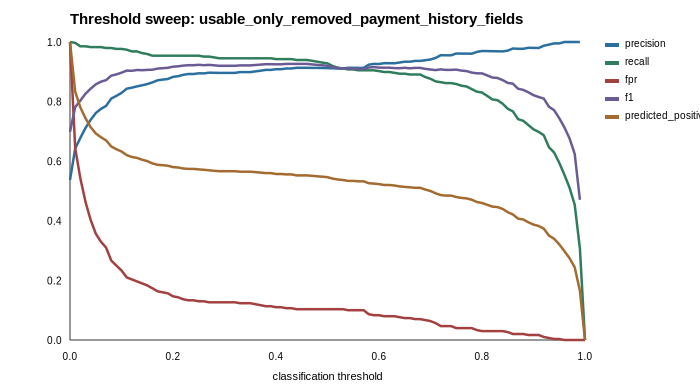

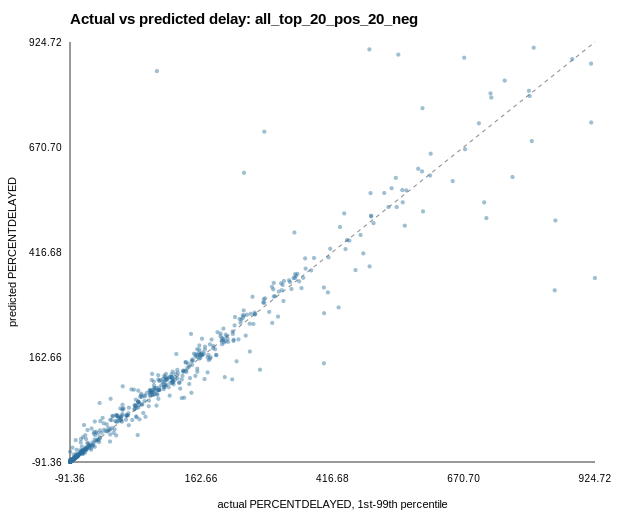

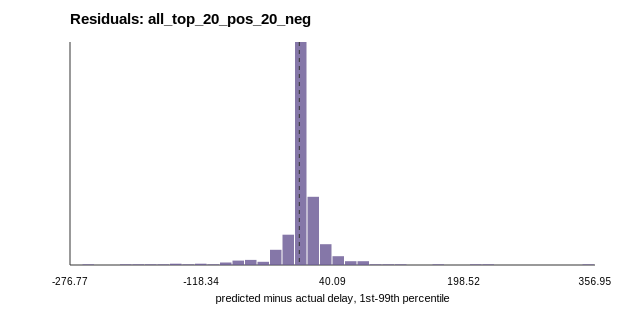

actual_bin_low,actual_bin_high,rows,mae,bias,actual_median,predicted_median
-94.29,-89.59,65.00,0.9496,0.9239,-90.57,-90.27
-89.59,-84.57,65.00,0.8283,0.7938,-88.00,-87.69
-84.57,-73.45,65.00,1.9935,1.7896,-80.26,-79.14
-73.45,-43.59,64.00,8.0949,6.4016,-63.64,-60.92
-43.59,22.07,65.00,17.23,13.61,-8.5526,7.9393
22.07,78.78,65.00,28.71,19.41,52.81,68.22
78.78,135.74,64.00,13.94,2.8734,104.17,107.57
135.74,219.37,65.00,17.80,-1.3128,167.86,169.35
219.37,400.00,64.00,59.60,35.48,284.61,300.24
400.00,"2,900.00",66.00,142.89,-36.54,590.38,568.69


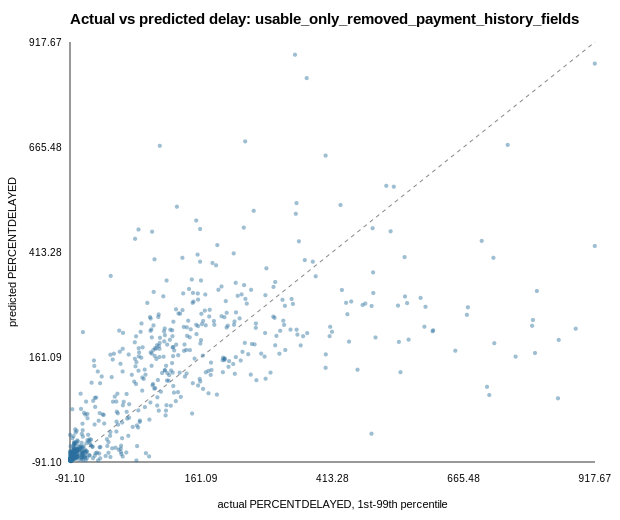

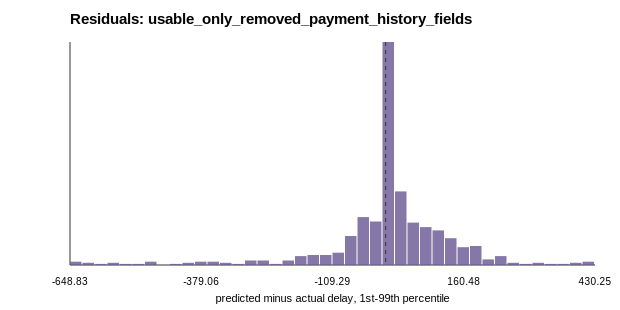

actual_bin_low,actual_bin_high,rows,mae,bias,actual_median,predicted_median
-94.29,-89.59,65.00,12.74,12.74,-90.57,-84.82
-89.59,-84.57,65.00,11.06,11.02,-88.00,-80.44
-84.57,-73.45,65.00,17.74,17.02,-80.26,-64.86
-73.45,-43.59,64.00,37.88,27.92,-63.64,-56.23
-43.59,22.07,65.00,75.23,36.02,-8.5526,8.1614
22.07,78.78,65.00,113.46,88.59,52.81,139.90
78.78,135.74,64.00,96.51,80.18,104.17,179.53
135.74,219.37,65.00,99.90,58.92,167.86,237.23
219.37,400.00,64.00,107.16,-1.2318,284.61,247.38
400.00,"2,900.00",66.00,407.78,-281.78,590.38,282.63


In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

prediction_scenarios = [name for name, _ in scenarios]

def rows_for_scenario(name):
    return [r for r in all_predictions if r['scenario'] == name]

def arr(rows, col):
    return np.array([float(r[col]) for r in rows], dtype=float)

def svg_multi_roc(prediction_rows_by_scenario, title='ROC curve: delayed vs not delayed', width=620, height=520):
    ml, mr, mt, mb = 70, 25, 45, 60
    w, h = width-ml-mr, height-mt-mb
    colors = ['#2b6f9f', '#9b4f96', '#2f7d5c', '#a35c2f']
    parts=[]
    legend=[]
    def sx(v): return ml + v*w
    def sy(v): return mt + h - v*h
    parts.append(f'<line x1="{sx(0)}" y1="{sy(0)}" x2="{sx(1)}" y2="{sy(1)}" stroke="#aaa" stroke-dasharray="4 4"/>')
    for i,(scenario, rows) in enumerate(prediction_rows_by_scenario.items()):
        y_true=arr(rows,'actual_delayed').astype(int)
        y_score=arr(rows,'predicted_delay_probability')
        fpr,tpr,thr=roc_curve(y_true,y_score)
        roc_auc=auc(fpr,tpr)
        pts=' '.join(f'{sx(x):.1f},{sy(y):.1f}' for x,y in zip(fpr,tpr))
        color=colors[i%len(colors)]
        parts.append(f'<polyline points="{pts}" fill="none" stroke="{color}" stroke-width="3"/>')
        legend.append((scenario, roc_auc, color))
    for t in np.linspace(0,1,6):
        parts.append(f'<line x1="{sx(t):.1f}" x2="{sx(t):.1f}" y1="{mt+h}" y2="{mt+h+5}" stroke="#333"/>')
        parts.append(f'<text x="{sx(t):.1f}" y="{mt+h+22}" text-anchor="middle" font-size="11">{t:.1f}</text>')
        parts.append(f'<line x1="{ml-5}" x2="{ml}" y1="{sy(t):.1f}" y2="{sy(t):.1f}" stroke="#333"/>')
        parts.append(f'<text x="{ml-10}" y="{sy(t)+4:.1f}" text-anchor="end" font-size="11">{t:.1f}</text>')
    ly=mt+12
    for scenario,roc_auc,color in legend:
        parts.append(f'<rect x="{ml+290}" y="{ly-10}" width="14" height="4" fill="{color}"/>')
        parts.append(f'<text x="{ml+310}" y="{ly-5}" font-size="11">{esc(scenario)} AUC={roc_auc:.3f}</text>')
        ly += 18
    body=''.join(parts)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="24" font-size="16" font-weight="600">{esc(title)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}<text x="{ml+w/2}" y="{height-12}" text-anchor="middle" font-size="12">False positive rate</text><text x="16" y="{mt+h/2}" transform="rotate(-90 16,{mt+h/2})" text-anchor="middle" font-size="12">True positive rate</text></svg>')

def threshold_sweep(rows, thresholds=None):
    if thresholds is None:
        thresholds=np.linspace(0,1,101)
    y_true=arr(rows,'actual_delayed').astype(int)
    y_score=arr(rows,'predicted_delay_probability')
    out=[]
    for th in thresholds:
        pred=(y_score>=th).astype(int)
        tp=int(((pred==1)&(y_true==1)).sum()); fp=int(((pred==1)&(y_true==0)).sum())
        tn=int(((pred==0)&(y_true==0)).sum()); fn=int(((pred==0)&(y_true==1)).sum())
        precision=tp/(tp+fp) if tp+fp else np.nan
        recall=tp/(tp+fn) if tp+fn else np.nan
        fpr=fp/(fp+tn) if fp+tn else np.nan
        f1=2*precision*recall/(precision+recall) if np.isfinite(precision) and np.isfinite(recall) and precision+recall else np.nan
        out.append({'threshold':float(th),'precision':precision,'recall':recall,'fpr':fpr,'f1':f1,'predicted_positive_rate':float(pred.mean())})
    return out

def svg_threshold_curves(rows, scenario, width=700, height=390):
    sweep=threshold_sweep(rows)
    ml,mr,mt,mb=70,115,42,50
    w,h=width-ml-mr,height-mt-mb
    colors={'precision':'#2b6f9f','recall':'#2f7d5c','fpr':'#a34040','f1':'#6b5b95','predicted_positive_rate':'#a36b2f'}
    parts=[]
    def sx(v): return ml+v*w
    def sy(v): return mt+h-v*h
    for metric,color in colors.items():
        pts=[]
        for r in sweep:
            v=r[metric]
            if np.isfinite(v): pts.append(f'{sx(r["threshold"]):.1f},{sy(v):.1f}')
        if pts:
            parts.append(f'<polyline points="{" ".join(pts)}" fill="none" stroke="{color}" stroke-width="2.5"/>')
    for t in np.linspace(0,1,6):
        parts.append(f'<text x="{sx(t):.1f}" y="{mt+h+20}" text-anchor="middle" font-size="10">{t:.1f}</text>')
        parts.append(f'<text x="{ml-8}" y="{sy(t)+4:.1f}" text-anchor="end" font-size="10">{t:.1f}</text>')
    ly=mt+10
    for metric,color in colors.items():
        parts.append(f'<rect x="{ml+w+20}" y="{ly-9}" width="14" height="4" fill="{color}"/>')
        parts.append(f'<text x="{ml+w+40}" y="{ly-5}" font-size="10">{metric}</text>')
        ly += 18
    body=''.join(parts)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="24" font-size="15" font-weight="600">Threshold sweep: {esc(scenario)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}<text x="{ml+w/2}" y="{height-10}" text-anchor="middle" font-size="11">classification threshold</text></svg>')

def svg_parity(rows, scenario, width=620, height=520):
    actual=arr(rows,'actual_percent_delayed')
    pred=arr(rows,'predicted_percent_delayed')
    lo,hi=np.percentile(np.r_[actual,pred],[1,99])
    if lo==hi: lo-=1; hi+=1
    ml,mr,mt,mb=70,25,42,58
    w,h=width-ml-mr,height-mt-mb
    def sx(v): return ml+(v-lo)/(hi-lo)*w
    def sy(v): return mt+h-(v-lo)/(hi-lo)*h
    parts=[]
    parts.append(f'<line x1="{sx(lo):.1f}" y1="{sy(lo):.1f}" x2="{sx(hi):.1f}" y2="{sy(hi):.1f}" stroke="#888" stroke-dasharray="4 4"/>')
    for a,p in zip(actual,pred):
        if lo <= a <= hi and lo <= p <= hi:
            parts.append(f'<circle cx="{sx(a):.1f}" cy="{sy(p):.1f}" r="2.1" fill="#2b6f9f" opacity="0.45"/>')
    for t in np.linspace(lo,hi,5):
        parts.append(f'<text x="{sx(t):.1f}" y="{mt+h+20}" text-anchor="middle" font-size="10">{esc(fmt(t,1))}</text>')
        parts.append(f'<text x="{ml-8}" y="{sy(t)+4:.1f}" text-anchor="end" font-size="10">{esc(fmt(t,1))}</text>')
    body=''.join(parts)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="24" font-size="15" font-weight="600">Actual vs predicted delay: {esc(scenario)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}<text x="{ml+w/2}" y="{height-12}" text-anchor="middle" font-size="11">actual PERCENTDELAYED, 1st-99th percentile</text><text x="16" y="{mt+h/2}" transform="rotate(-90 16,{mt+h/2})" text-anchor="middle" font-size="11">predicted PERCENTDELAYED</text></svg>')

def svg_residual_hist(rows, scenario, width=620, height=310, bins=42):
    actual=arr(rows,'actual_percent_delayed')
    pred=arr(rows,'predicted_percent_delayed')
    resid=pred-actual
    lo,hi=np.percentile(resid,[1,99])
    if lo==hi: lo-=1; hi+=1
    clipped=resid[(resid>=lo)&(resid<=hi)]
    counts,edges=np.histogram(clipped,bins=bins,range=(lo,hi))
    maxc=max(int(counts.max()),1)
    ml,mr,mt,mb=70,25,42,45
    w,h=width-ml-mr,height-mt-mb
    parts=[]
    for i,c in enumerate(counts):
        x=ml+i*w/bins; bw=w/bins-1; bh=h*c/maxc; y=mt+h-bh
        parts.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bw:.1f}" height="{bh:.1f}" fill="#6b5b95" opacity="0.82"/>')
    if lo < 0 < hi:
        zx=ml+(0-lo)/(hi-lo)*w
        parts.append(f'<line x1="{zx:.1f}" x2="{zx:.1f}" y1="{mt}" y2="{mt+h}" stroke="#333" stroke-dasharray="4 4"/>')
    for t in np.linspace(lo,hi,5):
        x=ml+(t-lo)/(hi-lo)*w
        parts.append(f'<text x="{x:.1f}" y="{mt+h+20}" text-anchor="middle" font-size="10">{esc(fmt(t,1))}</text>')
    body=''.join(parts)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="24" font-size="15" font-weight="600">Residuals: {esc(scenario)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}<text x="{ml+w/2}" y="{height-8}" text-anchor="middle" font-size="11">predicted minus actual delay, 1st-99th percentile</text></svg>')

def regression_bin_summary(rows, bins=10):
    actual=arr(rows,'actual_percent_delayed')
    pred=arr(rows,'predicted_percent_delayed')
    qs=np.unique(np.percentile(actual,np.linspace(0,100,bins+1)))
    out=[]
    for lo,hi in zip(qs[:-1],qs[1:]):
        m=(actual>=lo)&(actual<=hi if hi==qs[-1] else actual<hi)
        if m.sum()==0: continue
        err=pred[m]-actual[m]
        out.append({'actual_bin_low':lo,'actual_bin_high':hi,'rows':int(m.sum()),'mae':float(np.mean(np.abs(err))),'bias':float(np.mean(err)),'actual_median':float(np.median(actual[m])),'predicted_median':float(np.median(pred[m]))})
    return out

pred_by_scenario={s:rows_for_scenario(s) for s in prediction_scenarios}
display(svg_multi_roc(pred_by_scenario))

roc_summary=[]
for s,rows_s in pred_by_scenario.items():
    y_true=arr(rows_s,'actual_delayed').astype(int)
    y_score=arr(rows_s,'predicted_delay_probability')
    fpr,tpr,thr=roc_curve(y_true,y_score)
    roc_summary.append({'scenario':s,'roc_auc':float(auc(fpr,tpr)),'average_precision':float(average_precision_score(y_true,y_score)),'test_rows':len(rows_s),'positive_rate':float(y_true.mean())})
write_csv(f'{OUT_PREFIX}_roc_summary.csv', roc_summary)
display(table(roc_summary, ['scenario','roc_auc','average_precision','test_rows','positive_rate'], 'Binary probability ranking quality'))

for s,rows_s in pred_by_scenario.items():
    display(svg_threshold_curves(rows_s, s))
    sweep=threshold_sweep(rows_s, thresholds=np.linspace(0,1,21))
    for r in sweep:
        r['scenario']=s
    write_csv(f'{OUT_PREFIX}_{s}_threshold_sweep.csv', sweep)

display(HTML('<h3>Continuous regression diagnostics</h3>'))
for s,rows_s in pred_by_scenario.items():
    display(svg_parity(rows_s, s))
    display(svg_residual_hist(rows_s, s))
    bins=regression_bin_summary(rows_s)
    write_csv(f'{OUT_PREFIX}_{s}_regression_error_by_actual_bin.csv', bins)
    display(table(bins, ['actual_bin_low','actual_bin_high','rows','mae','bias','actual_median','predicted_median'], 'Regression error by actual-delay decile: '+s, max_rows=12))

## Feature Importance and Utility

Random-forest importance is not causal and can spread importance across correlated fields. It is still useful as a sanity check: if a field has high correlation but low model importance, its signal may be redundant with other selected fields.

In [8]:
for scenario in [s[0] for s in scenarios]:
    rows_imp=sorted([r for r in all_importances if r['scenario']==scenario], key=lambda r:-r['regression_importance'])
    display(table(rows_imp, ['feature','regression_importance','classification_importance','viability','comment'], f'Top regression importances: {scenario}', max_rows=25))
    rows_imp_cls=sorted([r for r in all_importances if r['scenario']==scenario], key=lambda r:-r['classification_importance'])
    display(table(rows_imp_cls, ['feature','classification_importance','regression_importance','viability','comment'], f'Top classification importances: {scenario}', max_rows=25))

feature,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,0.2823,0.0246,likely usable at project setup,Derived from planned start/end dates.
ITEMSTARTSPREADDAYS,0.2056,0.0252,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
PAYDATESPERPLANNEDMONTH,0.1489,0.0355,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
ITEMENDSPREADDAYS,0.1146,0.0253,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
DOLLARSPERPLANNEDMONTH,0.1102,0.1286,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
DOLLARSPERPLANNEDDAY,0.0948,0.1072,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
STDDEVUNITPRICE,0.0076,0.0483,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
CI_KW_MOBILIZATION,0.0072,0.0056,potentially usable after contract item setup,Derived from contract item descriptions; usable only if item text is available before prediction time.
STDDEVCONTRACTITEMPLANNEDVALUE,0.0050,0.0603,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
SHARESINGLEPAYDATEITEMS,0.0044,0.0034,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.


feature,classification_importance,regression_importance,viability,comment
DOLLARSPERPLANNEDMONTH,0.1286,0.1102,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
DOLLARSPERPLANNEDDAY,0.1072,0.0948,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
AVGUNITPRICE,0.0992,0.0016,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
MAXUNITPRICE,0.0972,0.0023,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVCONTRACTITEMPLANNEDVALUE,0.0603,0.0050,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVUNITPRICE,0.0483,0.0076,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
MEDIANCONTRACTBURN,0.0475,0.0013,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
MINCONTRACTBURN,0.0440,0.0001,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
MAXCONTRACTBURN,0.0397,0.0007,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.
AVGCONTRACTBURN,0.0375,0.0002,not usable before payment history,Retrospective payment/work-completion feature; useful diagnostically but leaks future activity for early prediction.


feature,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,0.4222,0.0458,likely usable at project setup,Derived from planned start/end dates.
DOLLARSPERCONTRACT,0.2256,0.0959,needs business review,Availability depends on when this field is populated in the operational workflow.
MAXUNITPRICE,0.1472,0.1540,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
AVGUNITPRICE,0.0635,0.1438,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVCONTRACTITEMPLANNEDVALUE,0.0468,0.1287,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVUNITPRICE,0.0324,0.1243,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
CMTEXTTOKENCOUNT,0.0166,0.0163,likely usable from setup text,Text-length/count feature from project/contract descriptions.
CMTEXTDISTINCTTOKENCOUNT,0.0110,0.0058,needs business review,Availability depends on when this field is populated in the operational workflow.
CI_KW_MOBILIZATION,0.0102,0.0719,potentially usable after contract item setup,Derived from contract item descriptions; usable only if item text is available before prediction time.
PMDESCRIPTIONTOKENCOUNT,0.0091,0.0292,likely usable from setup text,Text-length/count feature from project/contract descriptions.


feature,classification_importance,regression_importance,viability,comment
MAXUNITPRICE,0.1540,0.1472,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
AVGUNITPRICE,0.1438,0.0635,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVCONTRACTITEMPLANNEDVALUE,0.1287,0.0468,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
STDDEVUNITPRICE,0.1243,0.0324,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
DOLLARSPERCONTRACT,0.0959,0.2256,needs business review,Availability depends on when this field is populated in the operational workflow.
SHAREMISSINGORZEROPLANNEDVALUEITEMS,0.0779,0.0031,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
CI_KW_MOBILIZATION,0.0719,0.0102,potentially usable after contract item setup,Derived from contract item descriptions; usable only if item text is available before prediction time.
NUMMISSINGORZEROPLANNEDVALUEITEMS,0.0569,0.0033,potentially usable after contract item setup,Depends on item-level estimate/contract setup quality; not available before item schedule is defined.
PLANNEDDURATIONDAYS,0.0458,0.4222,likely usable at project setup,Derived from planned start/end dates.
PMDESCRIPTIONTOKENCOUNT,0.0292,0.0091,likely usable from setup text,Text-length/count feature from project/contract descriptions.


## Prediction Error Sanity Checks

The tables below show large test-set misses for each scenario. They are useful for seeing whether the model struggles with extreme early/late projects or with certain customer/project families.

In [9]:
for scenario in [s[0] for s in scenarios]:
    preds=[r for r in all_predictions if r['scenario']==scenario]
    for r in preds:
        r['absolute_error']=abs(r['predicted_percent_delayed']-r['actual_percent_delayed'])
        r['signed_error']=r['predicted_percent_delayed']-r['actual_percent_delayed']
    worst=sorted(preds, key=lambda r:-r['absolute_error'])[:20]
    display(table(worst, ['scenario','CUSTOMERNAME','PROJECTNAME','actual_percent_delayed','predicted_percent_delayed','absolute_error','actual_delayed','predicted_delay_probability'], f'Largest regression misses: {scenario}', max_rows=20))

scenario,CUSTOMERNAME,PROJECTNAME,actual_percent_delayed,predicted_percent_delayed,absolute_error,actual_delayed,predicted_delay_probability
all_top_20_pos_20_neg,UDOT,US-89 (500 W); 500 S to Bulldog Blvd in Provo,227.42,"1,718.82","1,491.40",1.0000,0.9849
all_top_20_pos_20_neg,Adams,2017 MANHOLE GRADE COMPLETION,"2,900.00","1,747.28","1,152.72",1.0000,0.8635
all_top_20_pos_20_neg,CCD,General Storm - Torreys Peak,76.87,854.39,777.52,1.0000,0.3531
all_top_20_pos_20_neg,UDOT,US-6 Over Price River Parapet Repairs (4F 390),725.00,"1,404.86",679.86,1.0000,0.9774
all_top_20_pos_20_neg,UDOT,I-80 EB Ramp over Main St Girder Repairs (2F-627),650.00,"1,234.45",584.45,1.0000,0.9279
all_top_20_pos_20_neg,UDOT,"SR-23; Drainage Improvements, Mendon",924.49,353.69,570.80,1.0000,0.9998
all_top_20_pos_20_neg,CCD,2024 - Wellshire Golf Cart Bridge,846.67,324.02,522.64,1.0000,0.8140
all_top_20_pos_20_neg,UDOT,I-80; Structure Replacement (MP 101 and 99),284.77,707.60,422.83,1.0000,0.9677
all_top_20_pos_20_neg,Lincoln,test project,488.14,906.77,418.64,1.0000,0.6100
all_top_20_pos_20_neg,UDOT,"2000 West & 1300 North Intersection, Clinton","1,786.21","1,416.58",369.62,1.0000,1.0000


scenario,CUSTOMERNAME,PROJECTNAME,actual_percent_delayed,predicted_percent_delayed,absolute_error,actual_delayed,predicted_delay_probability
usable_only_removed_payment_history_fields,UDOT,SR-201; Drainage and Pavement Improvements,590.91,"2,388.83","1,797.92",1.0000,0.9904
usable_only_removed_payment_history_fields,UDOT,"2000 West & 1300 North Intersection, Clinton","1,786.21",436.28,"1,349.93",1.0000,0.9921
usable_only_removed_payment_history_fields,Adams,2017 MANHOLE GRADE COMPLETION,"2,900.00","1,832.76","1,067.24",1.0000,0.7028
usable_only_removed_payment_history_fields,UDOT,MUTCD Curve Sign Updates (R1),"1,236.36",246.87,989.50,1.0000,0.9608
usable_only_removed_payment_history_fields,UDOT,I-80 EB Ramp over Main St Girder Repairs (2F-627),650.00,"1,468.23",818.23,1.0000,0.8454
usable_only_removed_payment_history_fields,UDOT,"North & South Main St. Overlay Phase 2, Coalville",986.44,172.67,813.77,1.0000,0.9944
usable_only_removed_payment_history_fields,CCD,2024 - Wellshire Golf Cart Bridge,846.67,61.87,784.80,1.0000,0.6218
usable_only_removed_payment_history_fields,UDOT,US-6 Over Price River Parapet Repairs (4F 390),725.00,"1,429.79",704.79,1.0000,0.8803
usable_only_removed_payment_history_fields,UDOT,"SR-23; Drainage Improvements, Mendon",924.49,262.02,662.47,1.0000,0.9930
usable_only_removed_payment_history_fields,UDOT,US-50; Bridge (0C-733) Repair,880.56,229.04,651.52,1.0000,0.9972


## Interpretation Summary

This cell writes a compact summary based on the executed metrics. The key comparison is between the full top-correlate model and the usability-filtered model.

In [10]:
summary=[]
full_reg=reg_metrics[0]; usable_reg=reg_metrics[1]
full_cls=cls_metrics[0]; usable_cls=cls_metrics[1]
summary.append('The all-top-correlate model uses '+str(full_reg['features'])+' fields, including retrospective payment-history fields.')
summary.append('The usable-only model uses '+str(usable_reg['features'])+' fields after removing '+str(len(unusable_features))+' payment-history-dependent fields.')
summary.append('Regression R2 changed from '+fmt(full_reg['r2'],3)+' to '+fmt(usable_reg['r2'],3)+' after removing non-usable fields.')
summary.append('Regression MAE changed from '+fmt(full_reg['mae'],2)+' to '+fmt(usable_reg['mae'],2)+'.')
summary.append('Classification ROC AUC changed from '+fmt(full_cls['roc_auc'],3)+' to '+fmt(usable_cls['roc_auc'],3)+'.')
summary.append('If the all-top model is materially stronger, that advantage should be treated as diagnostic rather than deployable because it can rely on payment cadence, burn, and spread fields that are only known after work has progressed.')
summary.append('The usable-only model is the better proxy for whether project metadata, contract/item setup, and text fields can support early delay risk scoring.')
display(HTML('<ul>'+''.join('<li>'+esc(s)+'</li>' for s in summary)+'</ul>'))
with open(f'{OUT_PREFIX}_summary.md','w',encoding='utf-8') as f:
    f.write('# Project Delay Random Forest Summary\n\n')
    for s in summary:
        f.write('- '+s+'\n')